# 01 — Random Forest

| 項目 | 設定 |
|------|------|
| 特徵集 | 全部 33 個特徵（原始 + 差值） |
| 標準化 | 不需要（樹模型） |
| VIF 檢查 | 不需要（樹模型） |
| 缺失處理 | SimpleImputer(median)，僅 fit train |
| 輸出 | rf_predictions.csv、rf_metrics.csv、feature_importance_rf.png |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, brier_score_loss,
                              classification_report, confusion_matrix)
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family']       = 'Microsoft JhengHei'
matplotlib.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = next(
    path for path in [Path('..').resolve(), Path('.').resolve()]
    if (path / 'data' / 'processed' / 'model_ready_games.csv').exists()
)
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_ready_games.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
METRICS_DIR = OUTPUT_DIR / 'metrics'
PREDICTIONS_DIR = OUTPUT_DIR / 'predictions'
FIGURES_DIR = OUTPUT_DIR / 'figures'
for path in [METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## 1. 讀取資料與切分

In [2]:
df = pd.read_csv(DATA_PATH, dtype={'year': str})

ID_COLS   = {'game_id', 'season_id', 'year', 'phase', 'date', 'home_team', 'away_team'}
LABEL     = 'home_win'
FEAT_COLS = [c for c in df.columns if c not in ID_COLS and c != LABEL]

# 2026 不納入建模
df = df[df['year'] != '2026'].copy()

train = df[df['year'].isin([str(y) for y in range(2018, 2025)])].copy()
test  = df[df['year'] == '2025'].copy()

X_train, y_train = train[FEAT_COLS], train[LABEL].astype(int)
X_test,  y_test  = test[FEAT_COLS],  test[LABEL].astype(int)

print(f'訓練集：{len(train)} 場（2018–2024）')
print(f'測試集：{len(test)} 場（2025）')
print(f'特徵數：{len(FEAT_COLS)}')

訓練集：1947 場（2018–2024）
測試集：358 場（2025）
特徵數：33


## 2. 缺失值填補（僅 fit train）

In [3]:
imputer     = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print(f'train 缺失率：{X_train.isna().mean().mean():.2%}')
print(f'test  缺失率：{X_test.isna().mean().mean():.2%}')

train 缺失率：2.15%
test  缺失率：1.31%


## 3. 訓練 RandomForestClassifier

In [4]:
rf = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 8,
    min_samples_leaf = 20,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_train_imp, y_train)
print('訓練完成')

訓練完成


## 4. 評估

In [5]:
y_pred = rf.predict(X_test_imp)
y_prob = rf.predict_proba(X_test_imp)[:, 1]

metrics = {
    'Model':        'Random Forest',
    'Feature_Set':  'All 33',
    'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
    'AUC':          round(roc_auc_score(y_test, y_prob), 4),
    'F1':           round(f1_score(y_test, y_pred), 4),
    'Brier_Score':  round(brier_score_loss(y_test, y_prob), 4),
}

for k, v in metrics.items():
    print(f'{k:<15}: {v}')

Model          : Random Forest
Feature_Set    : All 33
Accuracy       : 0.6927
AUC            : 0.7679
F1             : 0.7277
Brier_Score    : 0.2029


In [6]:
print(classification_report(y_test, y_pred, target_names=['客隊勝(0)', '主隊勝(1)']))

cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm,
             index   = ['實際客勝', '實際主勝'],
             columns = ['預測客勝', '預測主勝'])

              precision    recall  f1-score   support

      客隊勝(0)       0.68      0.62      0.65       163
      主隊勝(1)       0.70      0.75      0.73       195

    accuracy                           0.69       358
   macro avg       0.69      0.69      0.69       358
weighted avg       0.69      0.69      0.69       358



,預測客勝,預測主勝
實際客勝,101,62
實際主勝,48,147


## 5. 特徵重要性（Top 20）

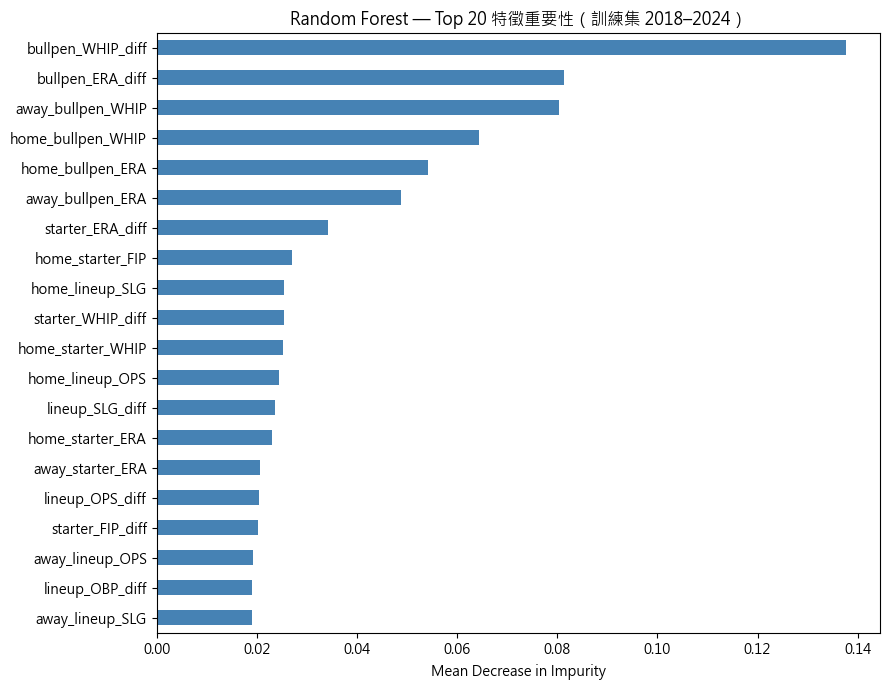

feature_importance_rf.png 已輸出


In [7]:
importances = (pd.Series(rf.feature_importances_, index=FEAT_COLS)
                 .sort_values(ascending=False))
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Top 20 特徵重要性（訓練集 2018–2024）')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_rf.png', dpi=150)
plt.show()
print('feature_importance_rf.png 已輸出')

## 6. 輸出 CSV

In [8]:
# predictions
pred_df = test[['game_id', 'date', 'home_team', 'away_team', LABEL]].copy()
pred_df['rf_pred']    = y_pred
pred_df['rf_prob']    = y_prob.round(4)
pred_df['rf_correct'] = (y_pred == y_test.values).astype(int)
pred_df.to_csv(PREDICTIONS_DIR / 'rf_predictions.csv', index=False, encoding='utf-8-sig')
print('rf_predictions.csv 已輸出')

# metrics
pd.DataFrame([metrics]).to_csv(METRICS_DIR / 'rf_metrics.csv', index=False)
print('rf_metrics.csv 已輸出')

rf_predictions.csv 已輸出
rf_metrics.csv 已輸出
